# Fraud Detection — 01. Подготовка данных и признаки
# Fraud Detection — 01. Data Preparation & Features

Первый из трёх ноутбуков проекта: загрузка и проверки данных, очистка,
разведочный анализ (EDA) и создание признаков. Результат сохраняется в
`data/processed/*.parquet`, чтобы следующий ноутбук (обучение моделей)
не пересчитывал всё заново.

First of three project notebooks: data loading and checks, cleaning,
exploratory data analysis (EDA) and feature engineering. The result is saved
to `data/processed/*.parquet` so the next notebook (model training) does not
have to recompute everything.

In [1]:
# System
import gc
import os
import random
import warnings
from pathlib import Path

# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
import joblib
import lightgbm as lgb
import optuna
import shap

from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# Settings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 200)

plt.style.use("ggplot")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)


/home/mchunikhin/miniconda3/envs/fraud/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Загрузка данных

## Data Loading

In [2]:
# Пути к данным
# Data paths
KAGGLE_PATH = "/kaggle/input/competitions/ieee-fraud-detection"

# Ищем корень проекта по наличию папки data (в текущей или родительских директориях)
# Find the project root by locating the data folder (in current or parent dirs)
def find_project_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "data" / "train_transaction.csv").exists():
            return base
    return None

PROJECT_ROOT = find_project_root()

if PROJECT_ROOT is not None:
    # Локальный запуск / Local run
    DATA_PATH = str(PROJECT_ROOT / "data")
    OUTPUT_DIR = PROJECT_ROOT
else:
    # Запуск на Kaggle / Kaggle run
    DATA_PATH = KAGGLE_PATH
    OUTPUT_DIR = Path("/kaggle/working")

# Каталоги для модели и сабмишена / Paths for model and submission
MODELS_DIR = str(Path(OUTPUT_DIR) / "models")
SUBMISSION_PATH = str(Path(OUTPUT_DIR) / "submission.csv")

# Загружаем transaction данные
# Load transaction data
train_tx = pd.read_csv(f"{DATA_PATH}/train_transaction.csv", index_col="TransactionID")
test_tx = pd.read_csv(f"{DATA_PATH}/test_transaction.csv", index_col="TransactionID")
# Загружаем identity данные
# Load identity data
train_id = pd.read_csv(f"{DATA_PATH}/train_identity.csv", index_col="TransactionID")
test_id = pd.read_csv(f"{DATA_PATH}/test_identity.csv", index_col="TransactionID")
# Загружаем sample submission
# Load sample submission
sample_sub = pd.read_csv(f"{DATA_PATH}/sample_submission.csv", index_col="TransactionID")
# Проверяем путь и размеры данных
# Check data path and shapes
print("DATA_PATH:", DATA_PATH)
print(f"Train transaction : {train_tx.shape}")
print(f"Train identity    : {train_id.shape}")
print(f"Test transaction  : {test_tx.shape}")
print(f"Test identity     : {test_id.shape}")

DATA_PATH: /home/mchunikhin/fraud_project/data
Train transaction : (590540, 393)
Train identity    : (144233, 40)
Test transaction  : (506691, 392)
Test identity     : (141907, 40)


## Preprocessing

In [3]:
# Объединяем train и test данные  transaction и identity
# Merge train and test: transaction + identity
train = train_tx.merge(train_id, how="left", left_index=True, right_index=True)
test = test_tx.merge(test_id, how="left", left_index=True, right_index=True)

In [4]:
# удаляем не нужные датафреймы, чтобы освободить память
# Delete unused dataframes to free memory
del train_tx
del train_id
del test_tx
del test_id
gc.collect()

20

In [5]:
# Обзор объединенного dataset
# Overview of merged dataset
train.head()

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1

In [6]:
train.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 590540 entries, 2987000 to 3577539
Columns: 433 entries, isFraud to DeviceInfo
dtypes: float64(399), int64(3), object(31)
memory usage: 1.9+ GB


In [7]:
train.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.0,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.0,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.0,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.0,1.839600e+04
card2,581607.0,3.625555e+02,1.577932e+02,100.000,214.000,361.000,512.0,6.000000e+02


Оптимизация памяти dataframe

Reducing dataframe memory usage

In [8]:
# Функция для уменьшения потребления памяти dataframe
# Function to reduce dataframe memory usage
def reduce_mem_usage(df):
    # Функция уменьшает потребление памяти dataframe за счёт оптимизации числовых типов данных
    # Reduce memory by optimizing numeric dtypes
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage before optimization: {start_mem:.2f} MB')
    for col in df.columns:
        col_type = df[col].dtype
        # Пропускаем object и category
        # Skip object and category columns
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            # Оптимизация integer
            # Optimize integer types
            if str(col_type)[:3] == 'int':
                if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            # Оптимизация float
            # Optimize float types
            else:
                if c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
        # Очистка памяти
        # Free memory
        gc.collect()
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage after optimization: {end_mem:.2f} MB')
    decrease = 100 * (start_mem - end_mem) / start_mem
    print(f'Decreased by {decrease:.1f}%')
    return df

In [9]:
train = reduce_mem_usage(train)

Memory usage before optimization: 1955.37 MB
Memory usage after optimization: 1046.96 MB
Decreased by 46.5%


In [10]:
test = reduce_mem_usage(test)

Memory usage before optimization: 1673.87 MB
Memory usage after optimization: 897.82 MB
Decreased by 46.4%


In [11]:
# Проверка совпадения типов данных
# Check dtype consistency
dtype_mismatch = []
common_cols = [col for col in train.columns if col in test.columns]
for col in common_cols:
    if train[col].dtype != test[col].dtype:
        dtype_mismatch.append((col, train[col].dtype, test[col].dtype))
print(f'Dtype mismatches: {len(dtype_mismatch)}')
dtype_mismatch[:10]

Dtype mismatches: 0


[]

In [12]:
# Проверяем, какие столбцы есть в train и test, чтобы избежать проблем с обучением модели
# Check column overlap between train and test to avoid training issues
train_only = set(train.columns) - set(test.columns)
test_only = set(test.columns) - set(train.columns)
print("Only in train:")
print(sorted(train_only))
print("\nOnly in test:")
print(sorted(test_only))

Only in train:
['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'isFraud']

Only in test:
['id-01', 'id-02', 'id-03', 'id-04', 'id-05', 'id-06', 'id-07', 'id-08', 'id-09', 'id-10', 'id-11', 'id-12', 'id-13', 'id-14', 'id-15', 'id-16', 'id-17', 'id-18', 'id-19', 'id-20', 'id-21', 'id-22', 'id-23', 'id-24', 'id-25', 'id-26', 'id-27', 'id-28', 'id-29', 'id-30', 'id-31', 'id-32', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38']


Исправляем разные названия столбцов

Checking dataset dimensions

In [13]:
print(train.shape)
print(test.shape)

(590540, 433)
(506691, 432)


In [14]:
# Исправляем несовпадение названий колонок
# Fix column name mismatches
test.columns = [col.replace('-', '_') for col in test.columns]

In [15]:
# Проверка
# Verification
train_only = set(train.columns) - set(test.columns)
test_only = set(test.columns) - set(train.columns)
print("Only in train:")
print(sorted(train_only))
print("\nOnly in test:")
print(sorted(test_only))

Only in train:
['isFraud']

Only in test:
[]


In [16]:
# Колонки сразу после объединения — точка отсчёта для статистики ниже
# Columns right after the merge — the baseline for the statistics below
raw_columns = train.columns.tolist()
print(f"Колонок после объединения / columns after merge: {len(raw_columns)}")

Колонок после объединения / columns after merge: 433


### Вывод

После memory optimization и preprocessing
типы данных в train и test полностью согласованы.

Это важно для корректного feature engineering,
encoding и обучения boosting-моделей.

### Summary

After memory optimization and preprocessing,
both train and test are ready for further work.

The next steps are feature engineering,
encoding, and training boosting models.

## EDA

### Общий обзор данных

### Dataset Overview

In [17]:
# Размер train и test datasets
# Train and test dataset shapes
print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')

Train shape: (590540, 433)
Test shape:  (506691, 432)


In [18]:
# Первые строки train dataset
# First rows of train dataset
train.head()

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1

In [19]:
# Общая информация о train dataset
# General info about train dataset
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 590540 entries, 2987000 to 3577539
Columns: 433 entries, isFraud to DeviceInfo
dtypes: float32(399), int16(1), int32(1), int8(1), object(31)
memory usage: 1.0+ GB


In [20]:
# Типы данных
# Data types
train.dtypes.value_counts()

float32    399
object      31
int8         1
int32        1
int16        1
Name: count, dtype: int64

In [21]:
# Проверка дублирующихся строк
# Check for duplicate rows
train_duplicates = train.duplicated().sum()
test_duplicates = test.duplicated().sum()
print(f'Train duplicates: {train_duplicates}')
print(f'Test duplicates:  {test_duplicates}')

Train duplicates: 3
Test duplicates:  0


In [22]:
# Удаляем дублирующиеся строки
# Remove duplicate rows
train = train.drop_duplicates()
print(f'Train shape after removing duplicates: {train.shape}')
print(f'Test shape after removing duplicates: {test.shape}')

Train shape after removing duplicates: (590537, 433)
Test shape after removing duplicates: (506691, 432)


### Вывод

В train dataset обнаружено только 3 дублирующиеся строки,
а в test duplicates отсутствуют,
что говорит о хорошем качестве данных.

Большая часть признаков в dataset анонимизирована,
поэтому основной акцент будет сделан
не на интерпретации отдельных колонок,
а на поиске паттернов, feature engineering
и построении устойчивых fraud detection моделей.

### Summary

The train dataset contained 3 duplicate rows,
while test had none —
which is expected for transactional data.

Since the dataset is already deduplicated,
the focus moves to
EDA, feature engineering,
and building an effective fraud detection model.

### Анализ target

### Target Variable

In [23]:
# Распределение target
# Target distribution
train['isFraud'].value_counts()

isFraud
0    569874
1     20663
Name: count, dtype: int64

In [24]:
# Процентное соотношение классов
# Class percentage ratio
train['isFraud'].value_counts(normalize=True) * 100

isFraud
0    96.500981
1     3.499019
Name: proportion, dtype: float64

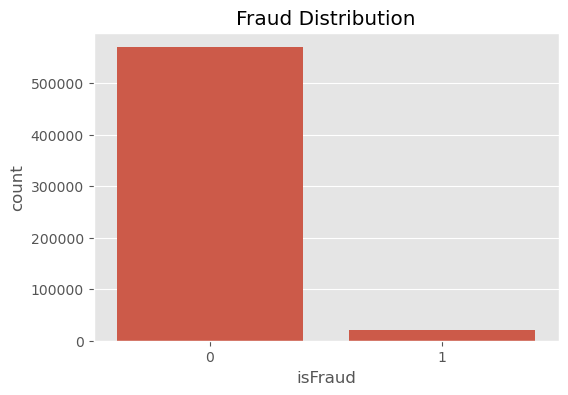

In [25]:
# Визуализация распределения target
# Visualize target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=train['isFraud'])
plt.title('Fraud Distribution')
plt.show()

In [26]:
# Доля fraud-транзакций
# Fraud ratio
fraud_ratio = train['isFraud'].mean() * 100
print(f'Fraud transactions: {fraud_ratio:.2f}%')

Fraud transactions: 3.50%


In [27]:
# Количество fraud и non-fraud транзакций
# Fraud and non-fraud transaction counts
fraud_count = train['isFraud'].value_counts()
print(f'Non-Fraud: {fraud_count[0]:,}')
print(f'Fraud:     {fraud_count[1]:,}')

Non-Fraud: 569,874
Fraud:     20,663


### Вывод

Dataset имеет сильный дисбаланс классов:  около **96.5%** транзакций являются обычными,  и только **~3.5%** относятся к fraud.
Из-за этого `accuracy` не подходит как основная метрика качества модели - для оценки моделей будем использовать **ROC-AUC**.

### Summary

The dataset is highly imbalanced:
**96.5%** of transactions are legitimate,
and only **~3.5%** are fraud.

Because of this, `accuracy` is not
a reliable metric — **ROC-AUC** is used instead.

### Анализ пропусков в числовых данных и категориальных

### Missing Values Analysis

In [28]:
# Процент пропусков в train
# Missing value percentage in train
train_missing = (train.isnull().mean() * 100).sort_values(ascending=False)
# Оставляем только колонки с пропусками
# Keep only columns with missing values
train_missing = train_missing[train_missing > 0]
train_missing.head(20)

id_24    99.196155
id_25    99.130960
id_08    99.127066
id_07    99.127066
id_21    99.126388
id_26    99.125711
id_22    99.124695
id_27    99.124695
id_23    99.124695
dist2    93.628342
D7       93.409896
id_18    92.360682
D13      89.509209
D14      89.469415
D12      89.040992
id_04    88.768866
id_03    88.768866
D6       87.606704
id_33    87.589431
id_09    87.312226
dtype: float64

In [29]:
# Процент пропусков в test
# Missing value percentage in test
test_missing = (test.isnull().mean() * 100).sort_values(ascending=False)
# Оставляем только колонки с пропусками
# Keep only columns with missing values
test_missing = test_missing[test_missing > 0]
test_missing.head(20)

id_24    99.064519
id_25    99.005508
id_26    99.003929
id_08    99.001561
id_07    99.001561
id_21    99.001561
id_23    99.000969
id_27    99.000969
id_22    99.000969
dist2    92.809030
id_18    89.959364
D7       88.132215
id_03    86.879380
id_04    86.879380
D12      86.332104
id_30    86.054814
id_32    86.052446
id_33    86.052446
id_14    85.917058
id_34    85.755618
dtype: float64

In [30]:
# Сравнение пропусков train vs test
# Compare missing values: train vs test
missing_compare = pd.DataFrame({'train_missing_%': train_missing, 'test_missing_%': test_missing})
missing_compare.head(20)

,train_missing_%,test_missing_%
C1,NaN,0.000592
C10,NaN,0.000592
C11,NaN,0.000592
C12,NaN,0.000592
C13,NaN,0.937060
C14,NaN,0.000592
C2,NaN,0.000592
C3,NaN,0.000592
C4,NaN,0.000592
C5,NaN,0.000592


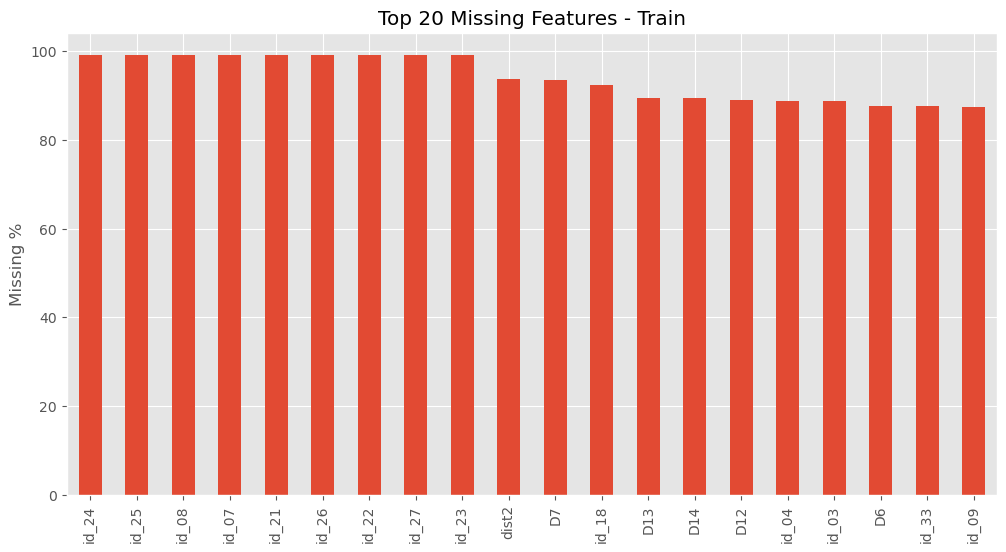

In [31]:
# Визуализация топ-20 колонок с пропусками
# Visualize top-20 columns with missing values
plt.figure(figsize=(12, 6))
train_missing.head(20).plot(kind='bar')
plt.title('Top 20 Missing Features - Train')
plt.ylabel('Missing %')
plt.show()

In [32]:
# Категориальные признаки
# Categorical features
cat_cols = train.select_dtypes(include='object').columns
# Процент пропусков в категориальных признаках
# Missing value % in categorical features
cat_missing = (train[cat_cols].isnull().mean() * 100).sort_values(ascending=False)
# Оставляем только признаки с пропусками
# Keep only features with missing values
cat_missing = cat_missing[cat_missing > 0]
cat_missing

id_27            99.124695
id_23            99.124695
id_33            87.589431
id_30            86.865345
id_34            86.824704
DeviceInfo       79.905408
id_16            78.097901
R_emaildomain    76.751499
id_31            76.245011
DeviceType       76.155601
id_29            76.127152
id_28            76.127152
id_15            76.125967
id_35            76.125967
id_36            76.125967
id_38            76.125967
id_37            76.125967
id_12            75.575959
M5               59.349372
M7               58.635276
M8               58.633075
M9               58.633075
M4               47.658656
M1               45.907200
M3               45.907200
M2               45.907200
M6               28.678813
P_emaildomain    15.994595
card4             0.267045
card6             0.266029
dtype: float64

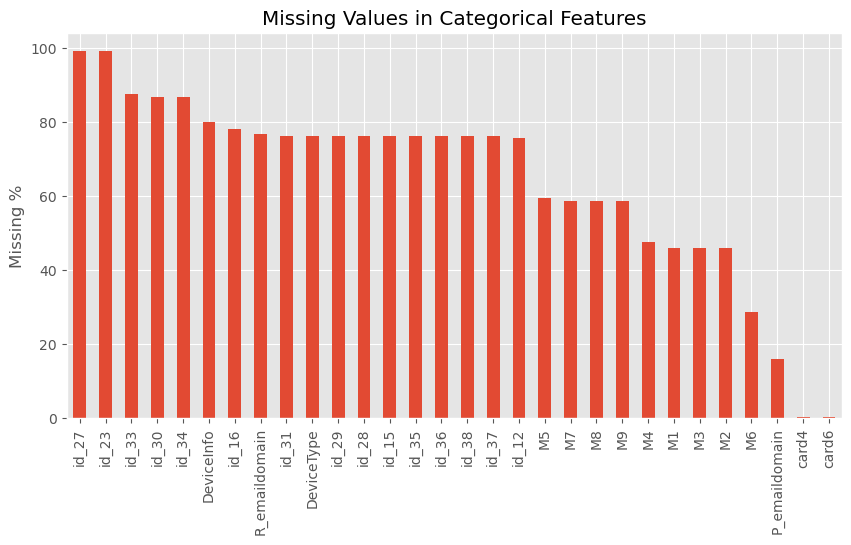

In [33]:
# Визуализация пропусков в категориальных признаках
# Visualize missing values in categorical features
plt.figure(figsize=(10, 5))
cat_missing.plot(kind='bar')
plt.title('Missing Values in Categorical Features')
plt.ylabel('Missing %')
plt.show()

### Вывод

В dataset присутствует большое количество пропусков,  особенно в identity и V-features.

Для fraud detection это является нормальной ситуацией, так как отсутствие информации само по себе может быть важным сигналом для модели.

Boosting-модели, такие как LightGBM и CatBoost, умеют эффективно работать с NaN значениями

Категориальные признаки также содержат большое количество пропусков, особенно в identity и device features. Для boosting-моделей пропуски могут содержать полезную информацию, поэтому на начальном этапе большинство NaN значений не будут удаляться или агрессивно заполняться.

### Summary

The dataset has a large number of missing values,
especially in identity and V-features.

For fraud detection this is expected,
since not every transaction has
all data points available.

Boosting models like LightGBM and CatBoost
can handle NaN values natively.

Categorical features may also benefit from
imputation with a dedicated "missing" category.

### Типы признаков

### Feature Types

In [34]:
# Количество признаков по типам данных
# Feature count by data type
train.dtypes.value_counts()

float32    399
object      31
int8         1
int32        1
int16        1
Name: count, dtype: int64

In [35]:
# Числовые признаки
# Numerical features
num_cols = train.select_dtypes(exclude='object').columns
print(f'Numerical features: {len(num_cols)}')

Numerical features: 402


In [36]:
# Категориальные признаки
# Categorical features
cat_cols = train.select_dtypes(include='object').columns
print(f'Categorical features: {len(cat_cols)}')

Categorical features: 31


In [37]:
# V-признаки
# V-features
v_features = [col for col in train.columns if col.startswith('V')]
print(f'V-features: {len(v_features)}')

V-features: 339


In [38]:
# D-признаки
# D-features
d_features = [col for col in train.columns if col.startswith('D')]
print(f'D-features: {len(d_features)}')

D-features: 17


In [39]:
# C-признаки
# C-features
c_features = [col for col in train.columns if col.startswith('C')]
print(f'C-features: {len(c_features)}')

C-features: 14


In [40]:
# Identity-признаки
# Identity features
id_features = [col for col in train.columns if col.startswith('id_')]
print(f'Identity features: {len(id_features)}')

Identity features: 38


In [41]:
# Device-признаки
# Device features
device_features = ['DeviceType', 'DeviceInfo']
print(device_features)

['DeviceType', 'DeviceInfo']


### Вывод

Dataset содержит большое количество анонимизированных признаков, включая группы `V-features`, `D-features` и `C-features`.

Большая часть признаков является числовой, что хорошо подходит для boosting-моделей.

Также dataset содержит identity и device features, которые могут быть полезны для выявления fraud-паттернов.

### Summary

The dataset contains many anonymized features:
`V-features`, `D-features`, and `C-features`.

These groups likely carry important signal
and are well-suited for boosting models.

Additionally, identity and device features
may help identify fraud patterns.

In [42]:
# Создаем временные признаки
# Create time features
def create_time_features(df):
    df['Transaction_hour'] = (df['TransactionDT'] // 3600) % 24
    df['Transaction_day'] = df['TransactionDT'] // (3600 * 24)
    df['Transaction_weekday'] = df['Transaction_day'] % 7
    return df

In [43]:
# Создаем признаки суммы транзакции
# Create transaction amount features
def create_amount_features(df):
    df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
    df['TransactionAmt_cents'] = df['TransactionAmt'] % 1
    return df

In [44]:
train = create_time_features(train)
test = create_time_features(test)
train = create_amount_features(train)
test = create_amount_features(test)

### TransactionAmt analysis

In [45]:
# Базовая статистика TransactionAmt
# TransactionAmt basic statistics
train['TransactionAmt'].describe()

count    590537.000000
mean        135.026840
std         239.162567
min           0.251000
25%          43.320999
50%          68.779999
75%         125.000000
max       31937.390625
Name: TransactionAmt, dtype: float64

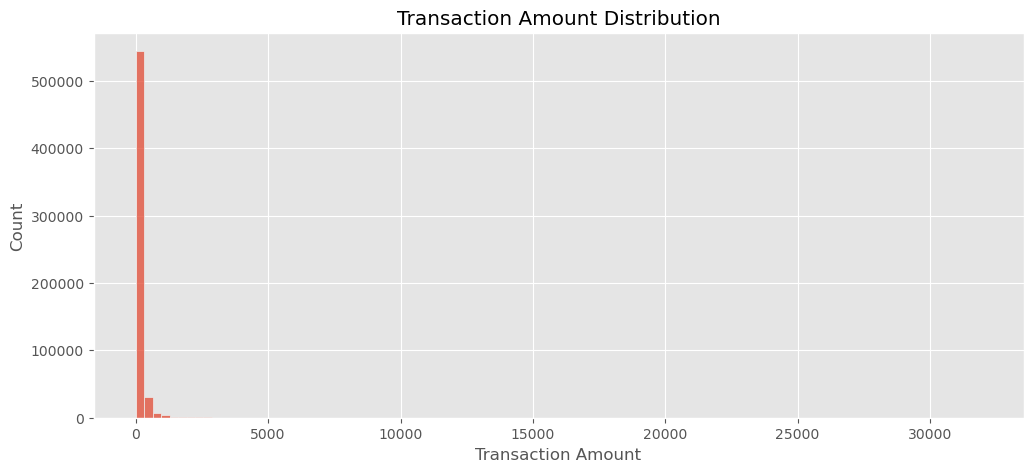

In [46]:
# Распределение TransactionAmt
# TransactionAmt distribution
plt.figure(figsize=(12, 5))
sns.histplot(train['TransactionAmt'], bins=100)
plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.show()

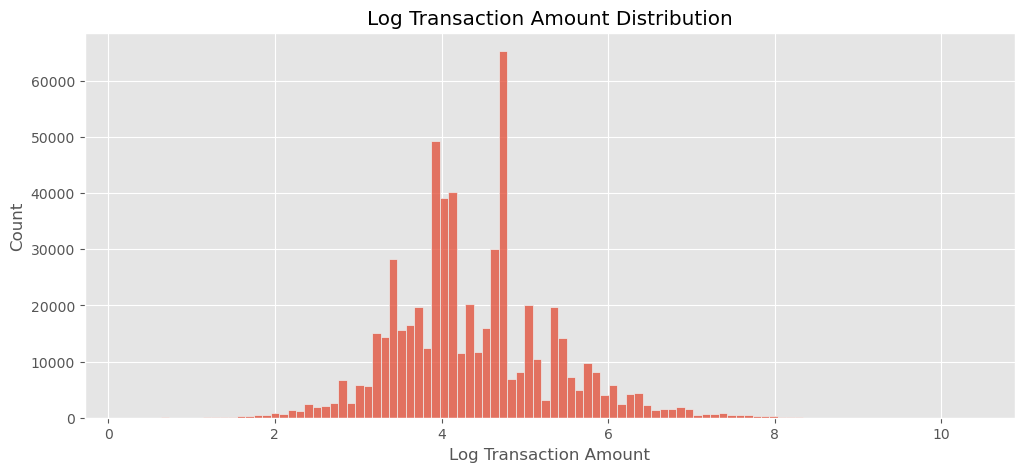

In [47]:
# Распределение после log transform
# Distribution after log transform
plt.figure(figsize=(12, 5))
sns.histplot(train['TransactionAmt_log'], bins=100)
plt.title('Log Transaction Amount Distribution')
plt.xlabel('Log Transaction Amount')
plt.show()

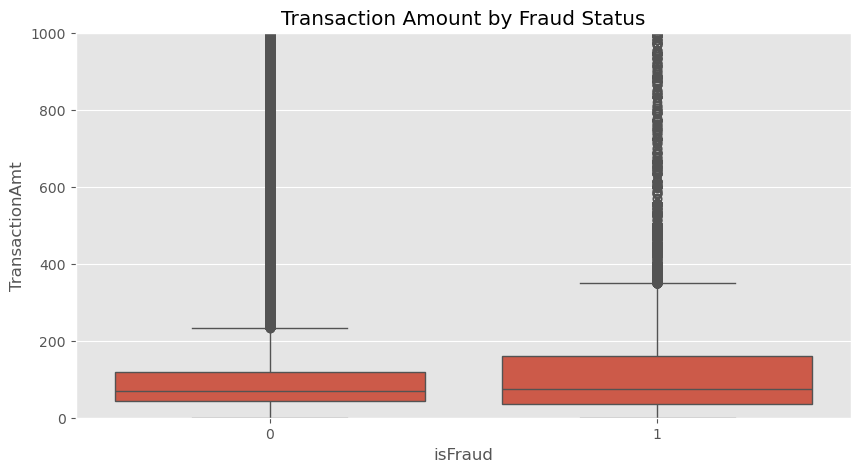

In [48]:
# Сравнение fraud vs non-fraud
# Fraud vs non-fraud comparison
plt.figure(figsize=(10, 5))
sns.boxplot(x='isFraud', y='TransactionAmt', data=train)
plt.title('Transaction Amount by Fraud Status')
plt.ylim(0, 1000)
plt.show()

In [49]:
# Средняя сумма транзакции
# Mean transaction amount
train.groupby('isFraud')['TransactionAmt'].mean()

isFraud
0    134.511307
1    149.244766
Name: TransactionAmt, dtype: float32

In [50]:
# Медианная сумма транзакции
# Median transaction amount
train.groupby('isFraud')['TransactionAmt'].median()

isFraud
0    68.5
1    75.0
Name: TransactionAmt, dtype: float32

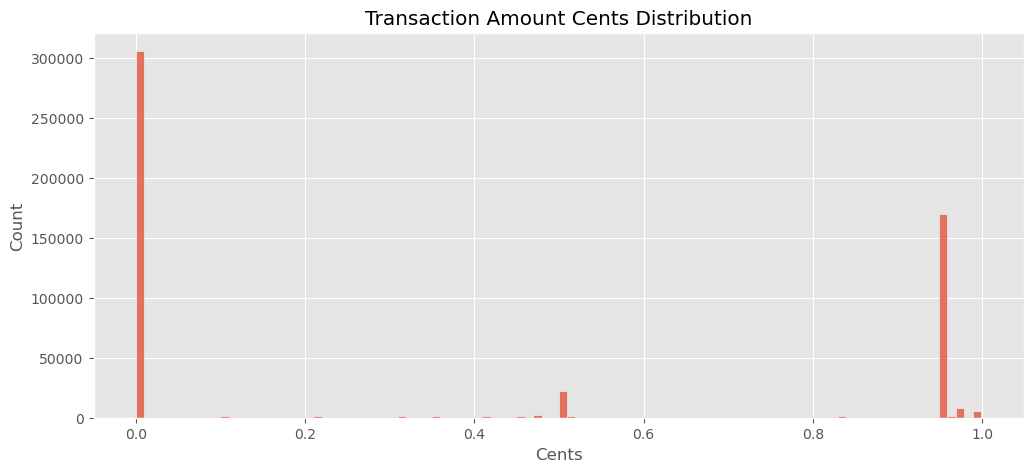

In [51]:
# Распределение cents
# Cents distribution
plt.figure(figsize=(12, 5))
sns.histplot(train['TransactionAmt_cents'], bins=100)
plt.title('Transaction Amount Cents Distribution')
plt.xlabel('Cents')
plt.show()

### Вывод

Признак `TransactionAmt` имеет сильное смещение вправо
и содержит большое количество выбросов.

После log-transform распределение становится более стабильным
и удобным для анализа и моделирования.

Также наблюдаются различия между fraud и non-fraud транзакциями,
что делает `TransactionAmt` одним из важных признаков проекта.

### Summary

`TransactionAmt` has a strong right-skewed distribution
and many outlier values.

After log-transform, the distribution becomes
more balanced and easier to work with.

There is also a visible difference
in amount distributions for fraud vs non-fraud,
making `TransactionAmt` a useful signal.

### Time analysis

In [52]:
# Fraud transactions по часам
# Fraud transactions by hour
hour_fraud = train.groupby('Transaction_hour')['isFraud'].mean()

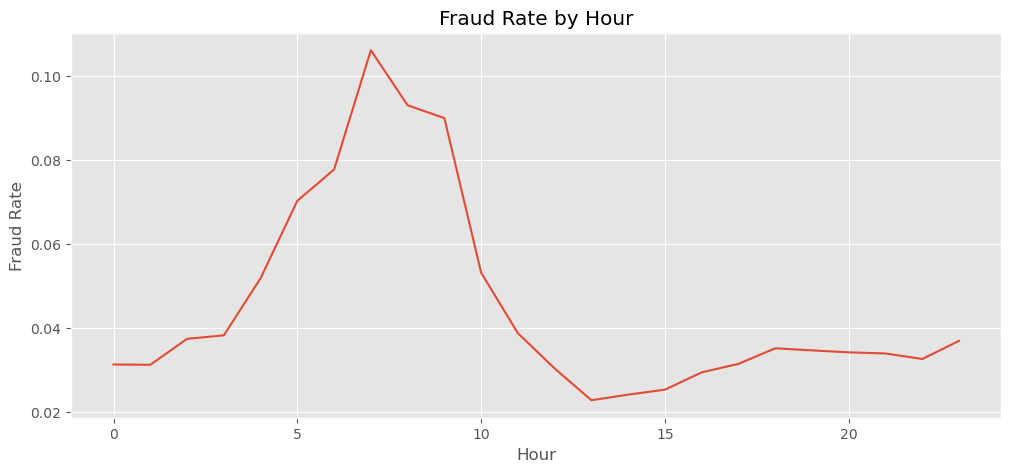

In [53]:
# Визуализация fraud rate по часам
# Visualize fraud rate by hour
plt.figure(figsize=(12, 5))
sns.lineplot(x=hour_fraud.index, y=hour_fraud.values)
plt.title('Fraud Rate by Hour')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')
plt.show()

In [54]:
# Fraud transactions по дням
# Fraud transactions by day
day_fraud = train.groupby('Transaction_day')['isFraud'].mean()

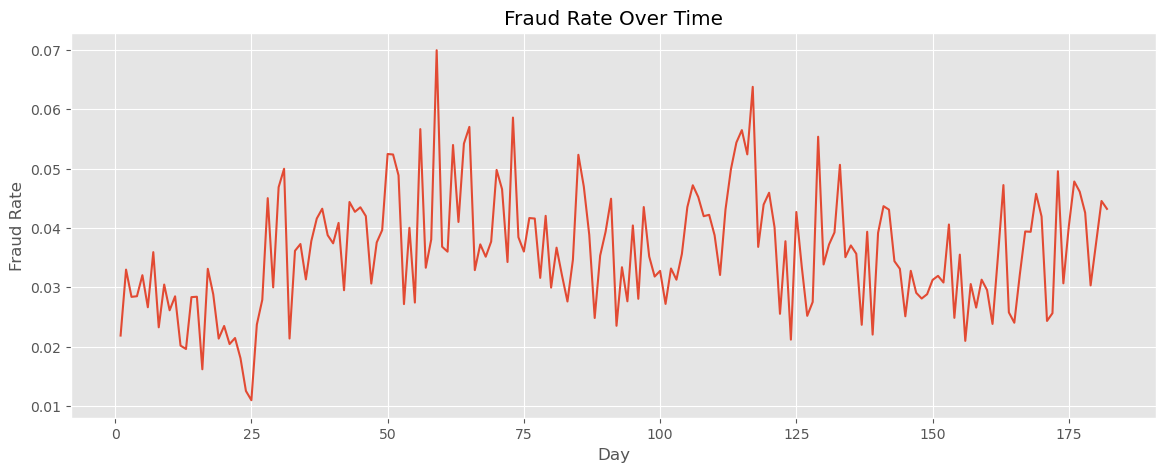

In [55]:
# Динамика fraud rate во времени
# Fraud rate over time
plt.figure(figsize=(14, 5))
sns.lineplot(x=day_fraud.index, y=day_fraud.values)
plt.title('Fraud Rate Over Time')
plt.xlabel('Day')
plt.ylabel('Fraud Rate')
plt.show()

In [56]:
# Fraud rate по дням недели
# Fraud rate by weekday
weekday_fraud = train.groupby('Transaction_weekday')['isFraud'].mean()

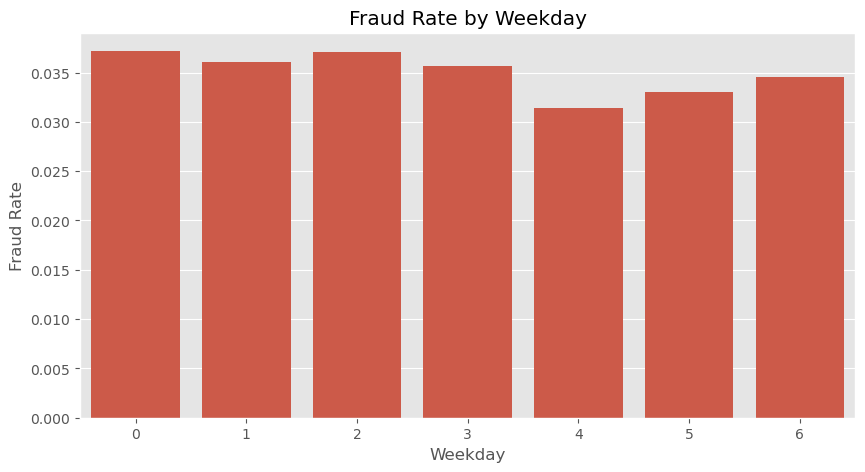

In [57]:
# Визуализация fraud rate по дням недели
# Visualize fraud rate by weekday
plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_fraud.index, y=weekday_fraud.values)
plt.title('Fraud Rate by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Fraud Rate')
plt.show()

In [58]:
# Количество транзакций по часам
# Transaction count by hour
hour_transactions = train.groupby('Transaction_hour').size()

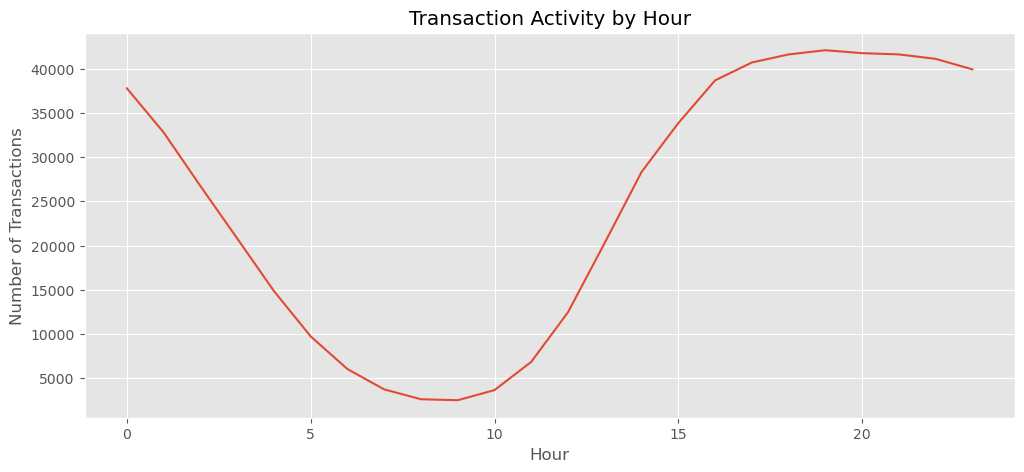

In [59]:
# Визуализация активности транзакций по часам
# Visualize transaction activity by hour
plt.figure(figsize=(12, 5))
sns.lineplot(x=hour_transactions.index, y=hour_transactions.values)
plt.title('Transaction Activity by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Transactions')
plt.show()

### Вывод

Во временных признаках наблюдаются выраженные temporal patterns.

Частота fraud-транзакций изменяется
в зависимости от времени суток и дня недели,
что делает `TransactionDT`
важным источником признаков для модели.

Полученные time features могут значительно улучшить качество fraud detection моделей.

### Summary

Strong temporal patterns were found.

Fraud activity peaks
at specific hours and days,
which means `TransactionDT`
carries meaningful temporal signal.

Adding time features will
likely improve the fraud detection model.

### Анализ категориальных признаков

### Categorical Feature Analysis

In [60]:
# Список категориальных признаков для анализа
# List of categorical features for analysis
cat_features = ['ProductCD', 'card4', 'card6', 'DeviceType', 'P_emaildomain']

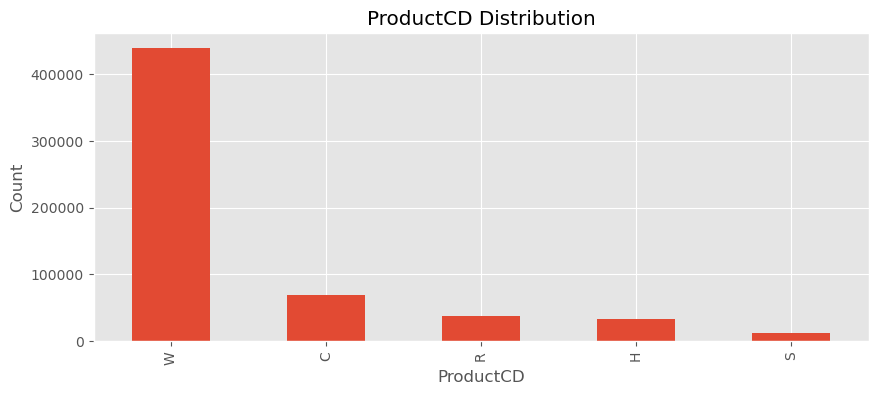

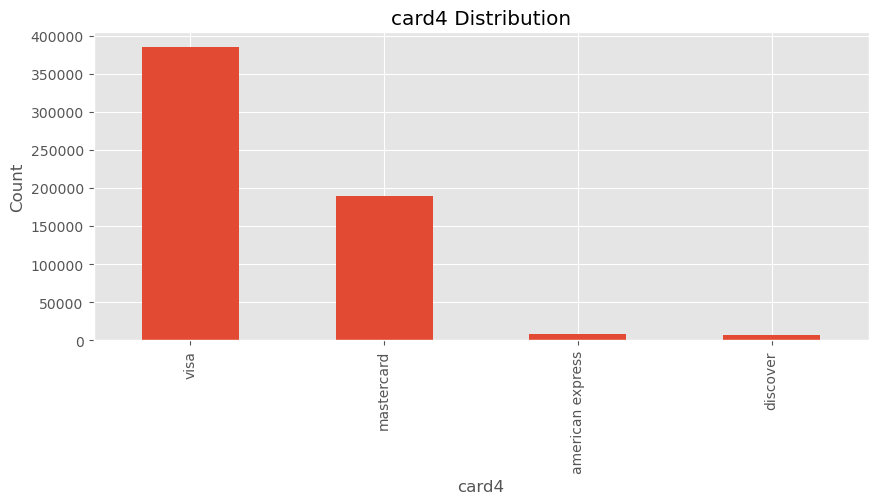

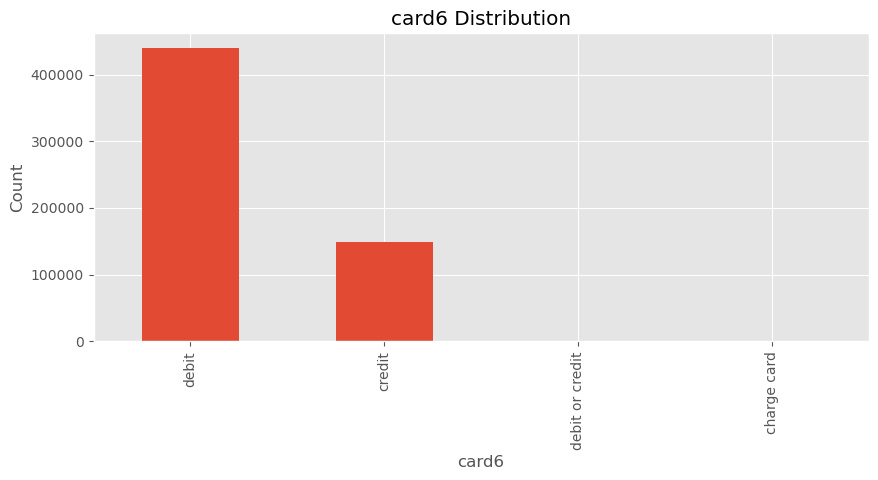

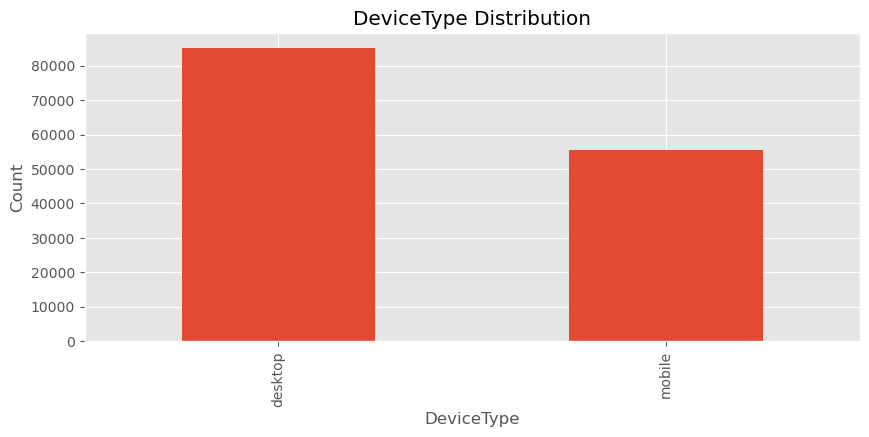

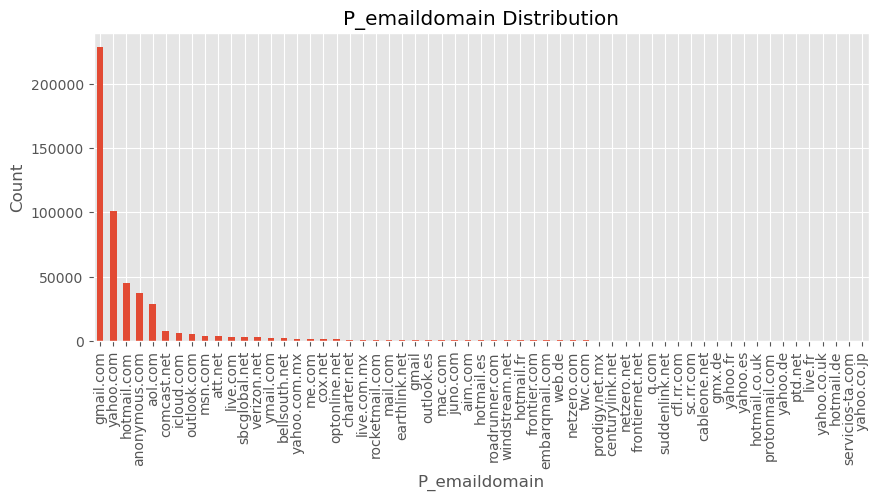

In [61]:
# Распределение категориальных признаков
# Categorical feature distributions
for col in cat_features:
    plt.figure(figsize=(10, 4))
    train[col].value_counts().plot(kind='bar')
    plt.title(f'{col} Distribution')
    plt.ylabel('Count')
    plt.show()

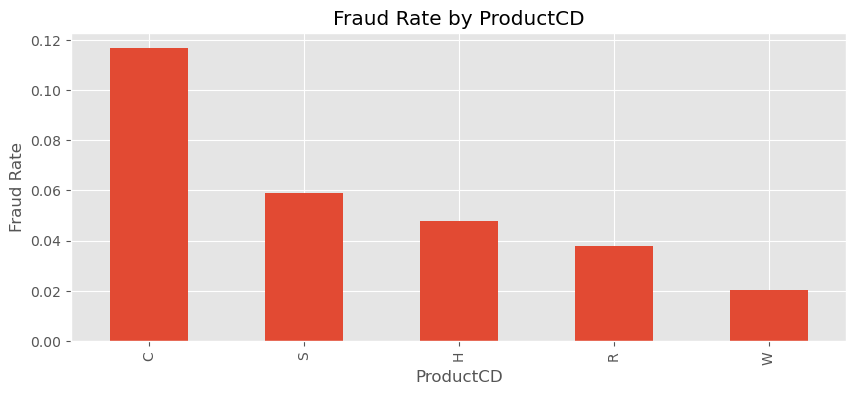

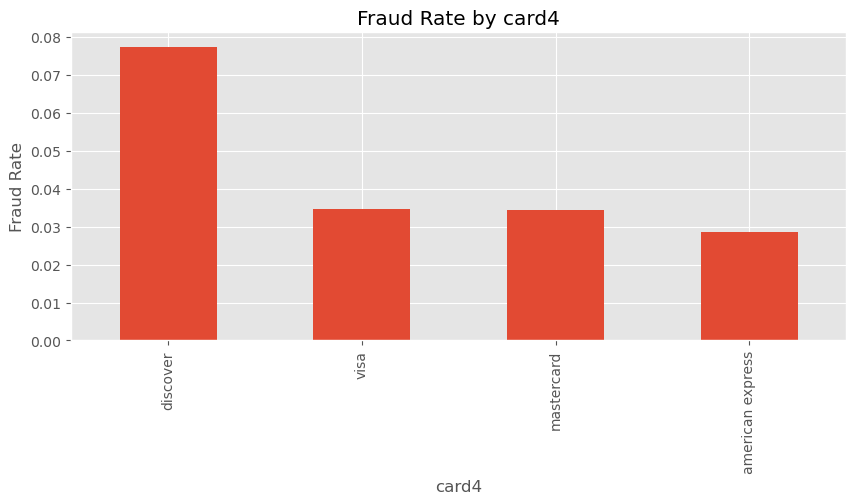

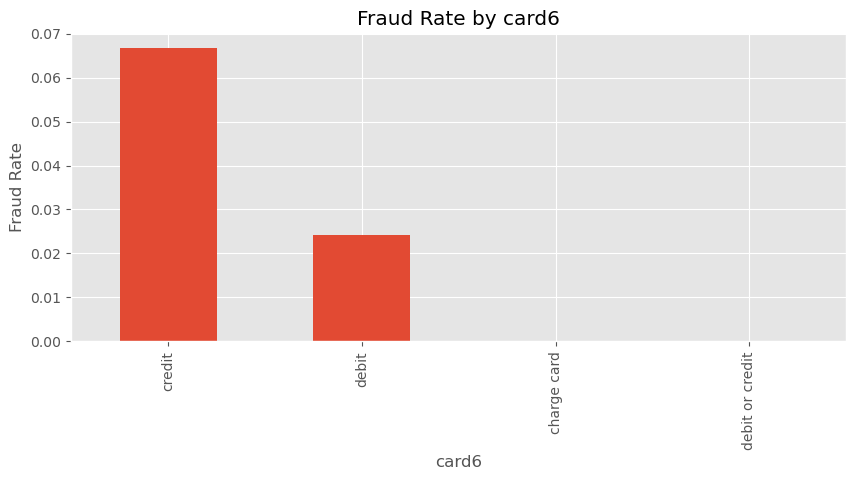

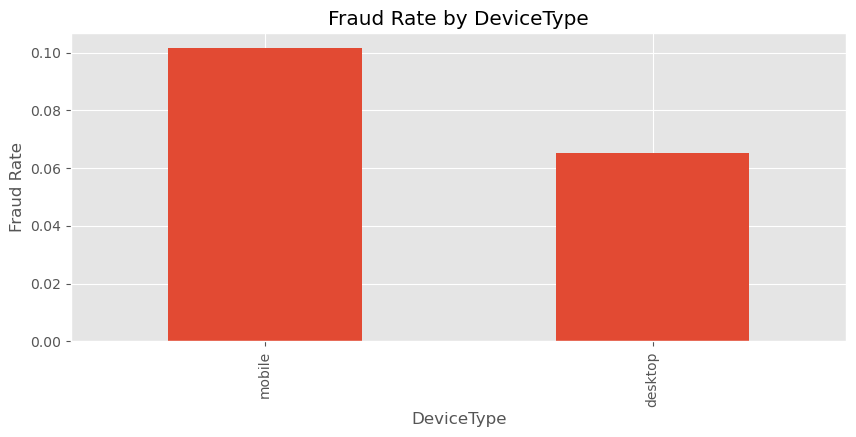

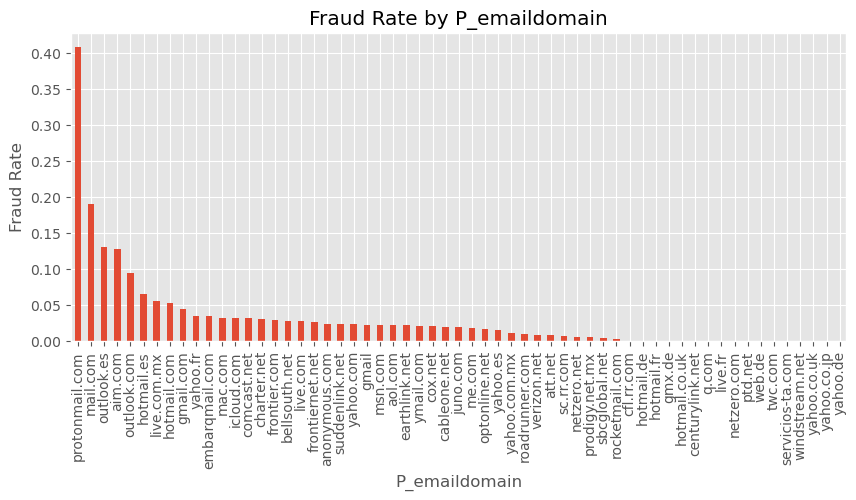

In [62]:
# Fraud rate по категориальным признакам
# Fraud rate by categorical feature
for col in cat_features:
    fraud_rate = train.groupby(col)['isFraud'].mean().sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    fraud_rate.plot(kind='bar')
    plt.title(f'Fraud Rate by {col}')
    plt.ylabel('Fraud Rate')
    plt.show()

In [63]:
# Топ email domains
# Top email domains
train['P_emaildomain'].value_counts().head(10)

P_emaildomain
gmail.com        228354
yahoo.com        100934
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033
Name: count, dtype: int64

In [64]:
# Типы устройств
# Device types
train['DeviceType'].value_counts(dropna=False)

DeviceType
NaN        449727
desktop     85165
mobile      55645
Name: count, dtype: int64

### Вывод

Некоторые категориальные признаки показывают заметные различия
между fraud и non-fraud транзакциями.

Особенно полезными выглядят:
- ProductCD
- card features
- email domains
- device information

Признак `ProductCD` является анонимизированным,
однако между его категориями наблюдаются
существенные различия по уровню fraud activity.

Это делает категориальные признаки
важной частью feature engineering
и fraud detection моделей.

### Summary

Categorical features show clear differences
between fraud and non-fraud transactions.

Key features include:
- ProductCD
- card features
- email domains
- device information

`ProductCD` is especially discriminative —
certain categories have much higher
fraud rates than others.

These categorical features deserve
focused feature engineering
for the fraud detection model.

### Train vs Test Distribution Analysis

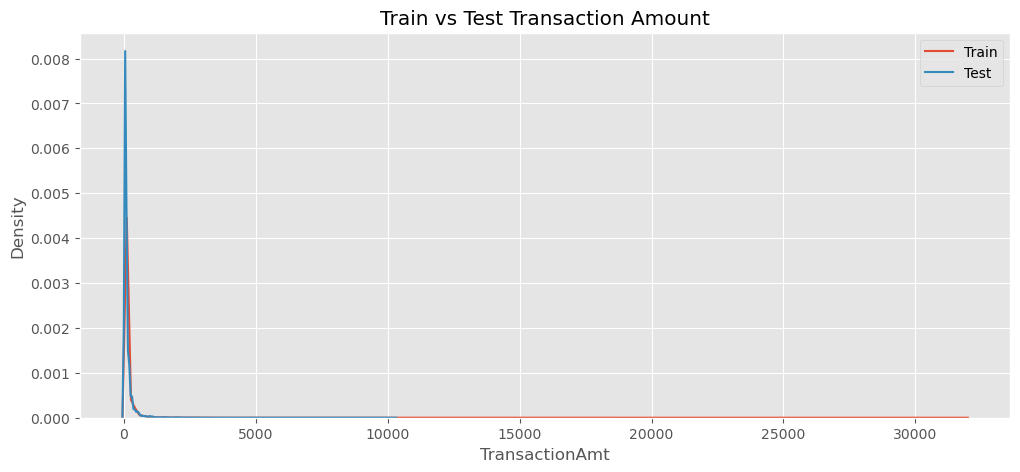

In [65]:
# Сравнение распределения TransactionAmt
# Compare TransactionAmt distributions
plt.figure(figsize=(12, 5))
sns.kdeplot(train['TransactionAmt'], label='Train')
sns.kdeplot(test['TransactionAmt'], label='Test')
plt.title('Train vs Test Transaction Amount')
plt.legend()
plt.show()

In [66]:
# Сравнение ProductCD distribution
# Compare ProductCD distribution
train_product = train['ProductCD'].value_counts(normalize=True)
test_product = test['ProductCD'].value_counts(normalize=True)
distribution_compare = pd.DataFrame({'train': train_product, 'test': test_product})
distribution_compare

,train,test
ProductCD,,
W,0.744521,0.712440
C,0.116028,0.136703
R,0.063839,0.070353
H,0.055922,0.057970
S,0.019691,0.022534


In [67]:
# Сравнение топ email domains
# Top email domains comparison
pd.DataFrame({
    'train': train['P_emaildomain']
        .value_counts(normalize=True)
        .head(10),
    'test': test['P_emaildomain']
        .value_counts(normalize=True)
        .head(10)
})

,train,test
P_emaildomain,,
anonymous.com,0.074580,0.077861
aol.com,0.057025,0.054967
att.net,0.008130,0.008261
comcast.net,0.015901,0.015054
gmail.com,0.460314,0.474168
hotmail.com,0.091215,0.092341
icloud.com,0.012633,0.013826
msn.com,0.008249,0.007744
outlook.com,0.010272,0.011058


### Вывод

Распределения признаков в train и test datasets
в целом выглядят достаточно похожими,
что говорит о хорошей согласованности данных.

При этом наблюдаются небольшие различия
в отдельных категориях и признаках,
что может быть связано с temporal drift —
типичной особенностью real-world fraud datasets.

Это важно учитывать при построении validation strategy
и оценке качества моделей.

### Summary

Distributions between train and test datasets
are generally similar,
though minor differences exist
in some features.

This is expected in fraud datasets
due to temporal drift
and real-world data shifts.

This analysis confirms the need
for a careful validation strategy
and model generalization checks.

## Data Cleaning & Missing Values

In [68]:
# Процент пропусков
# Missing value percentage
missing_percent = train.isnull().mean() * 100

In [69]:
# Колонки с экстремально большим количеством пропусков
# Columns with extremely high missing rate
high_missing_cols = missing_percent[missing_percent > 99].index.tolist()
print(f'Columns with >99% missing values: {len(high_missing_cols)}')

Columns with >99% missing values: 9


In [70]:
# Удаляем колонки с экстремально большим количеством пропусков
# Drop columns with extremely high missing rate
train = train.drop(columns=high_missing_cols)
test = test.drop(columns=high_missing_cols)
print(train.shape)
print(test.shape)

(590537, 429)
(506691, 428)


In [71]:
# Категориальные признаки
# Categorical features
cat_cols = train.select_dtypes(include='object').columns

In [72]:
# Заполняем пропуски в категориальных признаках
# Fill missing values in categorical features
for col in cat_cols:
    train[col] = train[col].fillna('missing')
    test[col] = test[col].fillna('missing')

In [73]:
# Проверяем оставшиеся пропуски
# Check remaining missing values
train[cat_cols].isnull().sum().sum()

np.int64(0)

In [74]:
# Колонки с одним уникальным значением
# Columns with a single unique value
single_unique_cols = [col for col in train.columns if train[col].nunique() <= 1]
print(f'Single unique columns: {len(single_unique_cols)}')

Single unique columns: 0


In [75]:
# Удаляем single unique columns
# Drop single-unique-value columns
if len(single_unique_cols) > 0:
    train = train.drop(columns=single_unique_cols)
    test = test.drop(columns=single_unique_cols)
print(train.shape)
print(test.shape)

(590537, 429)
(506691, 428)


## Создание признаков

## Feature Engineering

После анализа данных создаём новые признаки. Чтобы блок легко читался,
группируем признаки по тому, **как** они получены:

- **A. Напрямую из данных** — простые преобразования одной колонки
  (флаги, провайдер почты, признаки из времени и суммы).
- **B. Объединённые и производные** — признаки, которые объединяют несколько
  колонок или агрегируют информацию по многим строкам
  (идентификатор пользователя, частоты, агрегации, комбинации, нормализация).

Отдельно ниже разбираем большие анонимные группы признаков (V, C, D, M) и
делаем предположения об их смысле.

After exploring the data we build new features. To keep this section readable,
we group features by **how** they are made:

- **A. Directly from the data** — simple transformations of a single column
  (flags, email provider, time- and amount-based features).
- **B. Combined and derived** — features that join several columns or aggregate
  information across many rows (user id, frequencies, aggregations,
  interactions, normalization).

Separately, below we discuss the large anonymized feature groups (V, C, D, M)
and make assumptions about their meaning.

### Анонимные группы признаков: V / C / D / M

### Anonymized feature groups: V / C / D / M

Большинство колонок в данных обезличены, но по их поведению можно сделать
обоснованные предположения:

- **D-признаки (`D1…D15`)** — судя по всему, это **временные интервалы**
  («сколько дней прошло с какого-то события»). Их значения растут со временем —
  это пригодится в подгруппе про нормализацию (B5).
- **C-признаки (`C1…C14`)** — похоже на **счётчики** связанных с картой сущностей
  (адресов, телефонов, устройств и т. п.).
- **V-признаки (`V1…V339`)** — это, вероятно, признаки, уже созданные платёжной
  системой Vesta (связи, счётчики, отношения). Их много, оставляем как есть.
- **M-признаки (`M1…M9`)** — бинарные флаги совпадений (match / no match).

Вывод: эти группы оставляем модели как есть, но для **D**-группы дополнительно
сделаем версию, не зависящую от времени (см. подгруппу B5).

Most columns are anonymized, but their behaviour lets us make reasonable
assumptions:

- **D features (`D1…D15`)** — apparently **time deltas** ("how many days since
  some event"). Their values grow over time — this matters for the normalization
  subgroup (B5).
- **C features (`C1…C14`)** — look like **counts** of entities tied to the card
  (addresses, phones, devices, etc.).
- **V features (`V1…V339`)** — likely features already engineered by the payment
  provider Vesta (relations, counts, ratios). There are many; we keep them as is.
- **M features (`M1…M9`)** — binary match / no-match flags.

Conclusion: we keep these groups as is for the model, but for the **D** group we
also add a time-independent version (see subgroup B5).

In [76]:
# Размер каждой анонимной группы / Size of each anonymized group
for g in ["V", "C", "D", "M", "id_"]:
    cols = [c for c in train.columns if c.startswith(g)]
    print(f"{g:4s}: {len(cols)} columns")

V   : 339 columns
C   : 14 columns
D   : 17 columns
M   : 9 columns
id_ : 29 columns


### A. Признаки напрямую из данных

### A. Features extracted directly from the data

Простые преобразования отдельных колонок: модель и сама бы их «нашла», но в явном
виде они помогают ей быстрее. Simple transformations of individual columns: the
model could find them on its own, but giving them explicitly helps it learn faster.

#### A1. Из суммы транзакции / From the transaction amount

Из анализа: распределение суммы у мошеннических и обычных транзакций различается,
а у мошенников часто встречаются «круглые» суммы. Поэтому добавляем частоту суммы
и флаги круглой и крупной транзакции (логарифм и «копейки» уже посчитаны в EDA).

From the analysis: the amount distribution differs for fraud, and fraud often uses
"round" amounts. So we add the amount frequency and flags for round and large
transactions (the log and the "cents" were already computed during EDA).

In [77]:
# Частота значения суммы / Frequency of the amount value
train["TransactionAmt_frequency"] = train["TransactionAmt"].map(train["TransactionAmt"].value_counts())
test["TransactionAmt_frequency"]  = test["TransactionAmt"].map(test["TransactionAmt"].value_counts())

# Флаг круглой суммы (нет копеек) / Round-amount flag (no cents)
train["TransactionAmt_is_round"] = (train["TransactionAmt_cents"] == 0).astype(int)
test["TransactionAmt_is_round"]  = (test["TransactionAmt_cents"] == 0).astype(int)

# Флаг крупной суммы / Large-amount flag
train["TransactionAmt_large"] = (train["TransactionAmt"] > 500).astype(int)
test["TransactionAmt_large"]  = (test["TransactionAmt"] > 500).astype(int)

#### A2. Из времени / From time

Из анализа: доля мошенничества меняется по часам и дням недели. Базовые поля
(час, день, день недели) уже созданы в EDA — здесь добавляем флаги «выходной»
и «ночь».

From the analysis: the fraud rate varies by hour and weekday. The base fields
(hour, day, weekday) were already created during EDA — here we add the "weekend"
and "night" flags.

In [78]:
# Выходные и ночные транзакции / Weekend and night transactions
train["is_weekend"] = (train["Transaction_weekday"] >= 5).astype(int)
test["is_weekend"]  = (test["Transaction_weekday"] >= 5).astype(int)
train["is_night"]   = ((train["Transaction_hour"] <= 6) | (train["Transaction_hour"] >= 23)).astype(int)
test["is_night"]    = ((test["Transaction_hour"] <= 6) | (test["Transaction_hour"] >= 23)).astype(int)

#### A3. Из почты и устройства / From email and device

Из анализа: анонимность и отсутствие данных — сигнал риска. Достаём провайдера
почты, отмечаем совпадение адресов отправителя и получателя и отдельно — факт
отсутствия данных об устройстве.

From the analysis: anonymity and missing data are a risk signal. We extract the
email provider, flag when the purchaser and recipient emails match, and separately
flag missing device data.

In [79]:
# Провайдер почты (часть до первой точки) / Email provider (before the first dot)
for df in (train, test):
    df["P_email_provider"] = df["P_emaildomain"].str.split(".").str[0]
    df["R_email_provider"] = df["R_emaildomain"].str.split(".").str[0]

# Совпадение почты отправителя и получателя / Purchaser/recipient email match
train["email_match"] = (train["P_emaildomain"] == train["R_emaildomain"]).astype(int)
test["email_match"]  = (test["P_emaildomain"] == test["R_emaildomain"]).astype(int)

# Флаги отсутствия данных об устройстве / Missing-device flags
train["missing_device_info"] = (train["DeviceInfo"] == "missing").astype(int)
test["missing_device_info"]  = (test["DeviceInfo"] == "missing").astype(int)
train["missing_device_type"] = (train["DeviceType"] == "missing").astype(int)
test["missing_device_type"]  = (test["DeviceType"] == "missing").astype(int)

### B. Объединённые и производные признаки

### B. Combined and derived features

Эти признаки объединяют несколько колонок или используют статистику по многим
строкам. Именно они обычно дают модели больше всего пользы. These features join
several columns or use statistics over many rows. They usually give the model the
most value.

#### B1. Идентификатор пользователя (UID) / User identifier (UID)

Прямого ID клиента в данных нет, поэтому склеиваем номера карт, адрес и почту в
искусственный идентификатор. Чем больше полей в связке, тем точнее «один владелец».

There is no direct customer ID, so we glue card numbers, address and email into an
artificial identifier. The more fields in the combination, the more precise the
"one owner".

In [80]:
# Склейки разной точности / Combinations of increasing precision
train["uid"]  = train["card1"].astype(str) + "_" + train["card2"].astype(str)
test["uid"]   = test["card1"].astype(str)  + "_" + test["card2"].astype(str)
train["uid2"] = train["uid"].astype(str)   + "_" + train["addr1"].astype(str)
test["uid2"]  = test["uid"].astype(str)    + "_" + test["addr1"].astype(str)
train["uid3"] = train["uid2"].astype(str)  + "_" + train["P_emaildomain"].astype(str)
test["uid3"]  = test["uid2"].astype(str)   + "_" + test["P_emaildomain"].astype(str)

#### B2. Частотное кодирование / Frequency encoding

Редкая карта или адрес — выше риск. Для каждого значения считаем, сколько раз оно
встречается во всех данных (train и test вместе), и записываем это число.

A rare card or address means higher risk. For each value we count how many times it
appears across all data (train and test together) and store that number.

In [81]:
# Частотное кодирование выбранных колонок / Frequency-encode the selected columns
freq_encode_cols = ["card1", "card2", "addr1", "P_emaildomain", "DeviceInfo", "uid"]
full_df = pd.concat([train, test], axis=0)
for col in freq_encode_cols:
    counts = full_df[col].value_counts(dropna=False)
    train[f"{col}_frequency"] = train[col].map(counts)
    test[f"{col}_frequency"]  = test[col].map(counts)
del full_df
gc.collect()

0

#### B3. Агрегации по пользователю / Per-user aggregations

Считаем «типичный чек» пользователя и карты: среднюю сумму, разброс и число
транзакций. Это позволяет модели сравнить текущую сумму с обычной для владельца —
украденной картой часто платят нетипично крупно.

We compute a user's and a card's "typical spend": the average amount, its spread and
the number of transactions. This lets the model compare the current amount with what
is usual for the owner — a stolen card is often used for unusually large purchases.

In [82]:
# Средняя/разброс/количество по UID и карте / Mean/spread/count per UID and card
full_df = pd.concat([train, test], axis=0)

uid_mean  = full_df.groupby("uid")["TransactionAmt"].mean()
uid_std   = full_df.groupby("uid")["TransactionAmt"].std()
uid_count = full_df.groupby("uid")["TransactionAmt"].count()
c1_mean   = full_df.groupby("card1")["TransactionAmt"].mean()
c1_std    = full_df.groupby("card1")["TransactionAmt"].std()
dev_count = full_df.groupby("DeviceInfo")["TransactionAmt"].count()

for df in (train, test):
    df["uid_TransactionAmt_mean"]   = df["uid"].map(uid_mean)
    df["uid_TransactionAmt_std"]    = df["uid"].map(uid_std)
    df["uid_transaction_count"]     = df["uid"].map(uid_count)
    df["card1_TransactionAmt_mean"] = df["card1"].map(c1_mean)
    df["card1_TransactionAmt_std"]  = df["card1"].map(c1_std)
    df["device_transaction_count"]  = df["DeviceInfo"].map(dev_count)

del full_df
gc.collect()

0

#### B4. Комбинации признаков / Interaction features

Мошенничество часто выдаёт не одно поле, а необычное сочетание. Поэтому склеиваем
пары признаков (пользователь × тип товара, карта × устройство и т. п.) в новые
категории.

Fraud is often revealed not by a single field but by an unusual combination. So we
glue pairs of features (user × product type, card × device, etc.) into new
categories.

In [83]:
# Пары признаков как новые категории / Pairs of features as new categories
train["uid_ProductCD"]    = train["uid"].astype(str)           + "_" + train["ProductCD"].astype(str)
test["uid_ProductCD"]     = test["uid"].astype(str)            + "_" + test["ProductCD"].astype(str)
train["card1_DeviceType"] = train["card1"].astype(str)         + "_" + train["DeviceType"].astype(str)
test["card1_DeviceType"]  = test["card1"].astype(str)          + "_" + test["DeviceType"].astype(str)
train["email_DeviceType"] = train["P_emaildomain"].astype(str) + "_" + train["DeviceType"].astype(str)
test["email_DeviceType"]  = test["P_emaildomain"].astype(str)  + "_" + test["DeviceType"].astype(str)
train["uid_addr1"]        = train["uid"].astype(str)           + "_" + train["addr1"].astype(str)
test["uid_addr1"]         = test["uid"].astype(str)            + "_" + test["addr1"].astype(str)

#### B5. Нормализация D-признаков по времени / Time-normalizing the D features

Колонки `D1…D15` — это счётчики дней («сколько дней прошло с какого-то события»).
Их значения постоянно растут со временем, поэтому модель может запоминать не суть,
а просто «когда» произошла транзакция — и хуже работает на будущих данных.

Решение простое: вычитаем из каждого счётчика номер текущего дня
(`D − Transaction_day`). Вместо вечно растущего числа получается относительная
величина, не зависящая от того, насколько далеко в будущем мы оказались.
Аналогия: вместо «какой сейчас год» удобнее «сколько тебе лет» — второе не устаревает.

Это улучшение реально помогло на скрытом тесте соревнования, а не только на
внутренней проверке.

The `D1…D15` columns are day counters ("how many days since some event"). Their
values keep growing over time, so the model may memorize not the essence but simply
"when" a transaction happened — and works worse on future data.

The fix is simple: subtract the current day number from each counter
(`D − Transaction_day`). Instead of an ever-growing number we get a relative value
that does not depend on how far into the future we are. Analogy: instead of "what
year is it now" it is better to use "how old are you".

This change genuinely helped on the competition's hidden test set, not only on our
internal validation.

In [84]:
# Относительные версии D-счётчиков / Relative versions of the D counters
d_norm_cols = [c for c in ["D1", "D2", "D3", "D4", "D5", "D6", "D7", "D8",
                           "D10", "D11", "D12", "D13", "D14", "D15"] if c in train.columns]
for col in d_norm_cols:
    train[col + "_norm"] = (train[col] - train["Transaction_day"]).astype("float32")
    test[col + "_norm"]  = (test[col]  - test["Transaction_day"]).astype("float32")
print(f"D-normalized columns: {len(d_norm_cols)}")

D-normalized columns: 14


### Кодирование категорий / Categorical encoding

Модели градиентного бустинга работают с числами, поэтому все оставшиеся текстовые
колонки (включая созданные UID и комбинации) переводим в числовые коды. Кодировщик
обучаем на train и test вместе, чтобы одинаковые значения получили одинаковый код.

Gradient boosting models work with numbers, so all remaining text columns (including
the UID and interaction columns) are turned into numeric codes. The encoder is fit on
train and test together so identical values get identical codes.

In [85]:
# Числовое кодирование всех оставшихся текстовых колонок
# Numeric encoding of all remaining text columns
full_df = pd.concat([train, test], axis=0)
cat_cols = full_df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    le.fit(full_df[col].astype(str))
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))
del full_df
gc.collect()
print(f"encoded {len(cat_cols)} categorical columns")

encoded 38 categorical columns


## Итог: добавленные признаки

## Summary: engineered features

| Группа / Group | Признаки / Features | Зачем / Why |
|---|---|---|
| A1. Сумма / Amount | `TransactionAmt_frequency`, `TransactionAmt_is_round`, `TransactionAmt_large` (+ `_log`, `_cents` из EDA) | сумма различается у мошенников / amount differs for fraud |
| A2. Время / Time | `is_weekend`, `is_night` (+ `Transaction_hour/day/weekday` из EDA) | доля мошенничества зависит от времени / fraud rate depends on time |
| A3. Почта и устройство / Email & device | `P_email_provider`, `R_email_provider`, `email_match`, `missing_device_info`, `missing_device_type` | анонимность и пропуски — сигнал / anonymity & missingness |
| B1. Пользователь / User (UID) | `uid`, `uid2`, `uid3` | приблизительный ID владельца карты / approximate card-owner ID |
| B2. Частота / Frequency | `card1_frequency`, `card2_frequency`, `addr1_frequency`, `P_emaildomain_frequency`, `DeviceInfo_frequency`, `uid_frequency` | редкое значение — выше риск / rare value = higher risk |
| B3. Агрегации / Aggregations | `uid_TransactionAmt_mean/std`, `uid_transaction_count`, `card1_TransactionAmt_mean/std`, `device_transaction_count` | сравнение с типичным чеком / compare to typical spend |
| B4. Комбинации / Interactions | `uid_ProductCD`, `card1_DeviceType`, `email_DeviceType`, `uid_addr1` | необычные сочетания / unusual combinations |
| B5. Нормализация / Normalization | `D1_norm` … `D15_norm` | убираем зависимость от времени / remove time dependence |

In [86]:
# Статистика по колонкам: сколько удалили и добавили относительно исходных данных
# Column statistics: how many we removed and added vs the raw data
created_features = [c for c in train.columns if c not in raw_columns]
n_removed = len(high_missing_cols) + len(single_unique_cols)

print("=== Колонки / Columns ===")
print(f"После объединения (исходно) / after merge (raw):      {len(raw_columns)}")
print(f"Удалено при очистке / removed in cleaning:            {n_removed}"
      f"  (>99% пропусков / high-missing: {len(high_missing_cols)},"
      f" одно значение / single-value: {len(single_unique_cols)})")
print(f"Добавлено признаков / features added:                {len(created_features)}")
print(f"Итого колонок / final columns:                       {train.shape[1]}"
      f"  (рост vs исходных / growth vs raw: {train.shape[1] - len(raw_columns):+d})")
print(f"Форма / shape -> train: {train.shape} | test: {test.shape}")

print("\n=== Все созданные признаки / All created features ({}) ===".format(len(created_features)))
for f in created_features:
    print(" ", f)

=== Колонки / Columns ===
После объединения (исходно) / after merge (raw):      433
Удалено при очистке / removed in cleaning:            9  (>99% пропусков / high-missing: 9, одно значение / single-value: 0)
Добавлено признаков / features added:                48
Итого колонок / final columns:                       472  (рост vs исходных / growth vs raw: +39)
Форма / shape -> train: (590537, 472) | test: (506691, 471)

=== Все созданные признаки / All created features (48) ===
  Transaction_hour
  Transaction_day
  Transaction_weekday
  TransactionAmt_log
  TransactionAmt_cents
  TransactionAmt_frequency
  TransactionAmt_is_round
  TransactionAmt_large
  is_weekend
  is_night
  P_email_provider
  R_email_provider
  email_match
  missing_device_info
  missing_device_type
  uid
  uid2
  uid3
  card1_frequency
  card2_frequency
  addr1_frequency
  P_emaildomain_frequency
  DeviceInfo_frequency
  uid_frequency
  uid_TransactionAmt_mean
  uid_TransactionAmt_std
  uid_transaction_count
  ca

## Сохранение обработанных данных

## Save processed data

Сохраняем готовые таблицы в формате parquet (он хранит типы данных и читается за
секунды). Следующий ноутбук `fraud_02_modeling_tuning` берёт эти файлы и сразу
обучает модели — без повторной загрузки и пересчёта признаков.

We save the prepared tables in parquet format (it keeps dtypes and loads in
seconds). The next notebook `fraud_02_modeling_tuning` reads these files and trains
models right away — without reloading or recomputing the features.

In [87]:
# Каталог для обработанных данных / Folder for processed data
PROCESSED_DIR = os.path.join(DATA_PATH, "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

train_path = os.path.join(PROCESSED_DIR, "train.parquet")
test_path  = os.path.join(PROCESSED_DIR, "test.parquet")
train.to_parquet(train_path)
test.to_parquet(test_path)
print("saved:")
print(" ", train_path)
print(" ", test_path)

saved:
  /home/mchunikhin/fraud_project/data/processed/train.parquet
  /home/mchunikhin/fraud_project/data/processed/test.parquet
